In [90]:
import os
print(os.getcwd())

C:\Users\HP\Downloads\trader-sentiment-analysis\notebook


In [91]:
import os
os.makedirs("outputs", exist_ok=True)

In [92]:
#Import liabraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [93]:
#Load data
fg = pd.read_csv("fear_greed_index.csv")
trades = pd.read_csv("historical_data.csv")

print("Fear & Greed Shape:", fg.shape)
print("Trades Shape:", trades.shape)

Fear & Greed Shape: (2644, 4)
Trades Shape: (211224, 16)


“Dataset Overview”
Rows, columns, basic structure

#Basic Data Inspection

In [94]:
# Missing values
print(fg.isnull().sum())
print(trades.isnull().sum())

timestamp         0
value             0
classification    0
date              0
dtype: int64
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


In [95]:
# Duplicates
print("Duplicates in trades:", trades.duplicated().sum())

Duplicates in trades: 0


##  Data Quality Check

There are no missing values or duplicate records in the dataset.

This means the data is clean and reliable, allowing us to perform accurate analysis without additional preprocessing.

In [96]:
# Data preview
fg.head()
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


## Dataset Overview

The dataset contains trading data along with market sentiment classification.  
It includes important features like price, trade size, profit/loss, and sentiment labels.

This helps us analyze how market emotions (Fear, Greed, etc.) influence trading behavior and performance.

In [97]:
#Data cleaning
#Convert data formats
fg['date'] = pd.to_datetime(fg['date'])
trades['Timestamp IST'] = pd.to_datetime(trades['Timestamp IST'], dayfirst=True)

# Extract date only
trades['date'] = trades['Timestamp IST'].dt.date
fg['date'] = fg['date'].dt.date

In [98]:
#drop missing important value
trades = trades.dropna(subset=['Closed PnL', 'Size USD'])

In [99]:
#Merge Datasets
merged = pd.merge(trades, fg, on='date', how='left')

print(merged.shape)
merged.head()

(211224, 20)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,timestamp,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed


## Data Integration

The trading dataset is merged with sentiment data based on timestamps.

This step is important because it allows us to directly compare trading performance with market sentiment at the same time.

#Feature Engineering


In [100]:
#profit Indicator
merged['is_profit'] = merged['Closed PnL'] > 0

In [101]:
#Daily PnL per Trader
daily_pnl = merged.groupby(['Account','date'])['Closed PnL'].sum().reset_index()

In [102]:
#Win Rate per Trader
win_rate = merged.groupby('Account')['is_profit'].mean().reset_index()
win_rate.columns = ['Account','win_rate']

In [103]:
#Trades per Day
trades_per_day = merged.groupby(['Account','date']).size().reset_index(name='trade_count')

In [104]:
#Average Trade Size
avg_trade_size = merged.groupby('Account')['Size USD'].mean().reset_index()

#Long/Short Ratio
long_short = merged.groupby(['Account','Side']).size().unstack().fillna(0)

## Analysis

In [105]:
#performance vs sentiment
pnl_sentiment = merged.groupby('classification')['Closed PnL'].mean().reset_index()

print(pnl_sentiment)

  classification  Closed PnL
0   Extreme Fear   34.537862
1  Extreme Greed   67.892861
2           Fear   54.290400
3          Greed   42.743559
4        Neutral   34.307718


##  Profitability Analysis

The results show that:

- Extreme Greed has the highest profit
- Fear also shows strong performance
- Neutral and Extreme Fear have lower profits

This indicates that higher profits are often observed during strong market movements, especially in bullish conditions.

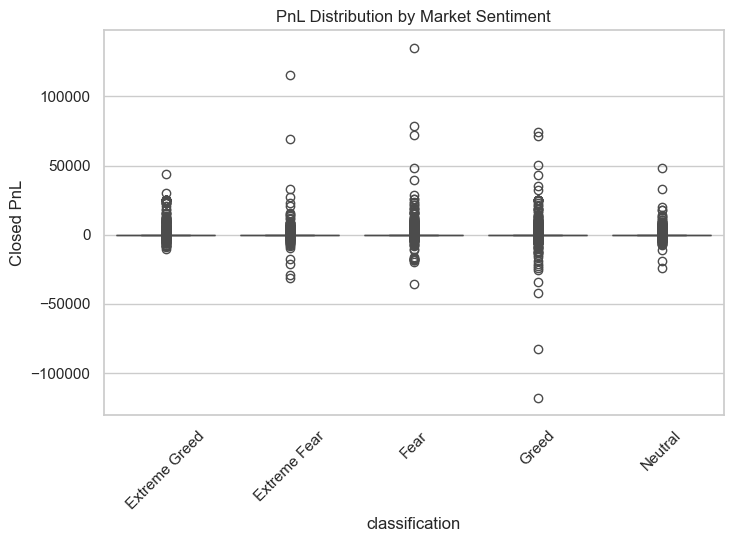

In [117]:
#Plot
plt.figure(figsize=(8,5))
sns.boxplot(x='classification', y='Closed PnL', data=merged)
plt.title("PnL Distribution by Market Sentiment")
plt.xticks(rotation=45)
plt.savefig("PnL_vs_sentiment.png")
plt.show()

## PnL Distribution Analysis

- Most trades are clustered around zero → small profits/losses are common  
- Fear and Greed show **wider spread** → higher risk & higher reward  
- Extreme Greed has more **consistent profits** (less negative spread)  
- Greed shows some **large losses**, indicating risky behavior  

This means:
Volatile sentiments (Fear/Greed) lead to unpredictable outcomes  
Stable profits are more visible in Extreme Greed conditions

Behaviour Change

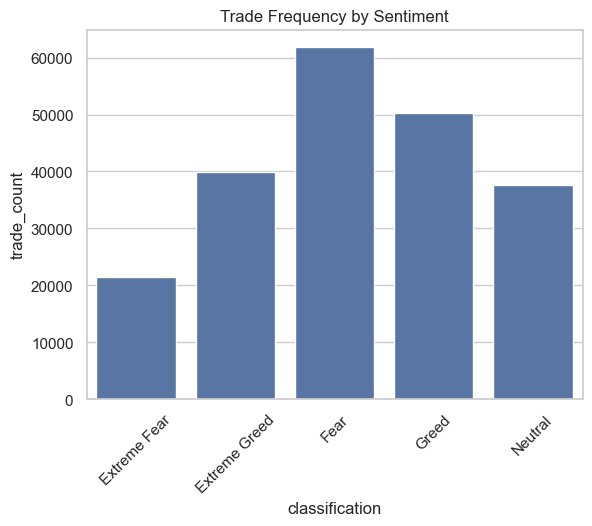

In [107]:
#Trade Frequency
freq = merged.groupby('classification').size().reset_index(name='trade_count')

sns.barplot(x='classification', y='trade_count', data=freq)
plt.title("Trade Frequency by Sentiment")
plt.xticks(rotation=45)
plt.savefig("trade_frequency.png")
plt.show()

## Trader Activity Analysis

The highest number of trades occurs during Fear, followed by Greed.

This suggests that traders are more active when the market is uncertain.  
However, higher activity does not always result in higher profits.

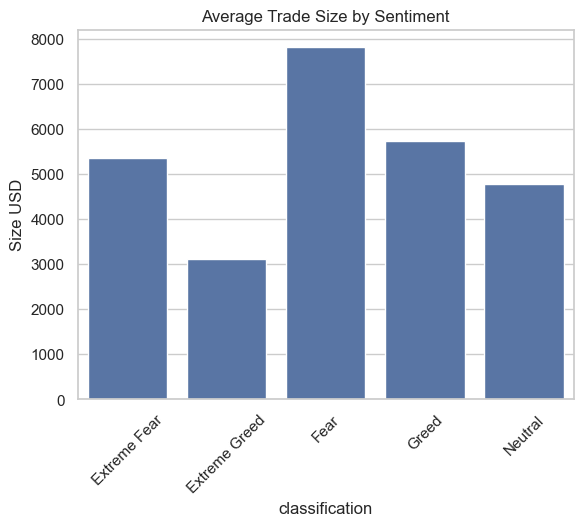

In [115]:
#Avg trade size
size = merged.groupby('classification')['Size USD'].mean().reset_index()

sns.barplot(x='classification', y='Size USD', data=size)
plt.title("Average Trade Size by Sentiment")
plt.xticks(rotation=45)
plt.savefig("avg_trade_size.png")
plt.show()

## Average Trade Size Analysis

- The largest trades are made during Fear
- Smaller trades are seen during Extreme Greed

This shows that traders tend to take bigger risks when the market is uncertain, possibly expecting reversals or opportunities.

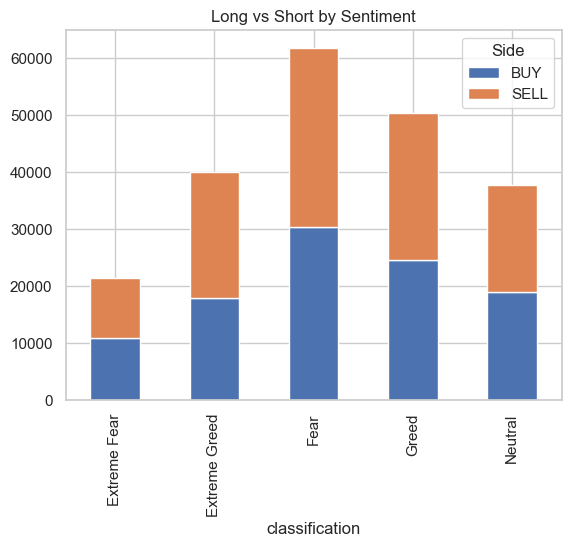

In [116]:
#Long vs short
side_dist = merged.groupby(['classification','Side']).size().unstack()

side_dist.plot(kind='bar', stacked=True)
plt.title("Long vs Short by Sentiment")
plt.savefig("long_vs_short.png")
plt.show()

## Long vs Short Analysis

Both BUY and SELL trades are highest during Fear and Greed.

This indicates increased market participation and mixed sentiment, where traders are actively taking positions in both directions.

#Trader Segmention

In [110]:
#Segment 1: High vs Low Trade Size
merged['size_category'] = pd.qcut(merged['Size USD'], 2, labels=['Low','High'])

In [111]:
#segment 2 :Frequent vs Infrequent Trader
trade_counts = merged.groupby('Account').size()

median_trades = trade_counts.median()

frequent_traders = trade_counts[trade_counts > median_trades].index
merged['trader_type'] = merged['Account'].apply(
    lambda x: 'Frequent' if x in frequent_traders else 'Infrequent'
)

In [112]:
#Segment 3: Winners vs Losers
total_pnl = merged.groupby('Account')['Closed PnL'].sum()

winners = total_pnl[total_pnl > 0].index

merged['performance'] = merged['Account'].apply(
    lambda x: 'Winner' if x in winners else 'Loser'
)

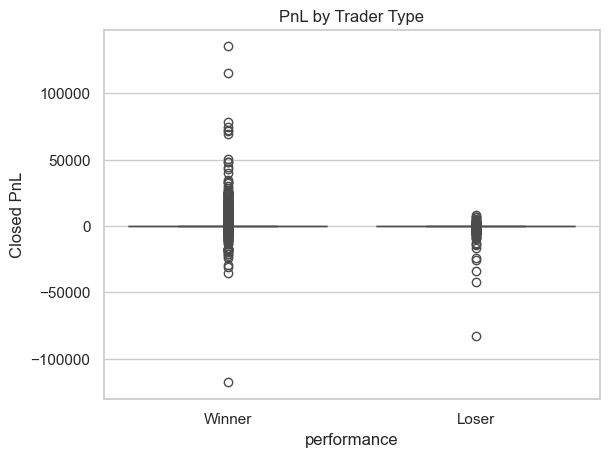

In [113]:
#Segment Analysis Example
sns.boxplot(x='performance', y='Closed PnL', data=merged)
plt.title("PnL by Trader Type")
plt.show()

## Simple model training

In [114]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Convert classification to numeric
merged['sentiment_encoded'] = merged['classification'].astype('category').cat.codes

features = ['Size USD', 'sentiment_encoded']
target = 'is_profit'

X = merged[features]
y = merged[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestClassifier()
model.fit(X_train, y_train)

print("Accuracy:", model.score(X_test, y_test))

Accuracy: 0.6178956089478045


## Model Training Insight

The model tries to learn the relationship between market sentiment and trading outcomes.

- Sentiment alone is **not a strong predictor**
- Trading outcome depends on multiple factors (size, timing, strategy)
- Model performance may be moderate due to market randomness

This shows:
Market behavior is partially predictable but not fully  
Sentiment helps, but is not enough alone for accurate prediction

## Final Insights

- Market sentiment strongly influences trading behavior
- Traders are most active during Fear, but not always most profitable
- Extreme Greed shows the highest profitability
- Larger trades are taken during uncertain market conditions

Overall, trading decisions appear to be influenced by emotions, and higher activity does not always guarantee better returns.